# **03: HYBRID ENSEMBLE**
### Purpose: Combine CNN-RNN with Random Forest for robust prediction
### Status: CURRENT BEST MODEL 
### Key Results: F1 Score = 0.7317, Optimal weight = 0.10 CNN + 0.90 RF
### Models Saved: cnn_rnn_hybridensemble.keras, rf_model_hybridensemble.pkl
### Next: Advanced stacking in 04_advanced_ensemble.ipynb

# Environment Setup

In [1]:
# 📦 Install Dependencies
%pip install pandas scikit-learn tensorflow matplotlib imbalanced-learn
%env SCIPY_ARRAY_API=1


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
env: SCIPY_ARRAY_API=1


# Imports

In [2]:
# 📦 ESSENTIAL IMPORTS ONLY
import numpy as np
import pandas as pd  
import matplotlib.pyplot as plt
import joblib
import sys
import os

# Scikit-learn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

# TensorFlow/Keras  
from tensorflow.keras.models import load_model

# Custom utilities
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.utils.data_utils import load_and_preprocess_data

# Data Loading & Preprocessing

In [3]:
# 1️⃣ LOAD AND PREPROCESS DATASET
print("📊 Loading UCI Machine Learning dataset for ensemble training...")
(X_train, X_test, y_train, y_test), scaler = load_and_preprocess_data("../data/dataset.csv")

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Class distribution: {np.bincount(y_train)}")

# Load pre-trained CNN-RNN model
print("🧠 Loading pre-trained CNN-RNN model...")
model = load_model("../models/cnn_rnn_model_dataset.keras")
print("✅ Model loaded successfully!")

📊 Loading UCI Machine Learning dataset for ensemble training...
Training set: (8000, 5, 1)
Test set: (2000, 5, 1)
Class distribution: [7722  278]
🧠 Loading pre-trained CNN-RNN model...


2025-11-11 15:13:06.913158: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2025-11-11 15:13:06.913261: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-11-11 15:13:06.913269: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
I0000 00:00:1762870386.913287 18757393 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1762870386.913315 18757393 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


✅ Model loaded successfully!


# Random Forest Training

In [4]:
# 2️⃣ TRAIN RANDOM FOREST ON FLATTENED DATA
print("🌲 Training Random Forest ensemble component...")

# Flatten 3D CNN data to 2D for Random Forest
X_train_rf = X_train.reshape(X_train.shape[0], -1)  # (samples, features*timesteps)
X_test_rf = X_test.reshape(X_test.shape[0], -1)

print(f"Flattened training shape: {X_train_rf.shape}")
print(f"Flattened test shape: {X_test_rf.shape}")

# Train Random Forest on flattened data
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_rf, y_train)
rf_probs = rf.predict_proba(X_test_rf)[:, 1]  # Get probability of class 1

print("✅ Random Forest training completed!")

🌲 Training Random Forest ensemble component...
Flattened training shape: (8000, 5)
Flattened test shape: (2000, 5)
✅ Random Forest training completed!


# CNN-RNN Predicitons

In [5]:
# 3️⃣ GET CNN-RNN PREDICTIONS
print("🧠 Generating CNN-RNN predictions...")

# Use pre-trained CNN-RNN model
cnn_probs = model.predict(X_test).flatten()  # Get probabilities

print(f"CNN predictions shape: {cnn_probs.shape}")
print(f"RF predictions shape: {rf_probs.shape}")
print("✅ Both model predictions ready for ensemble!")

🧠 Generating CNN-RNN predictions...


2025-11-11 15:13:17.923560: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
CNN predictions shape: (2000,)
RF predictions shape: (2000,)
✅ Both model predictions ready for ensemble!


# Ensemble Weight Optimization

In [6]:
# 4️⃣ OPTIMIZE ENSEMBLE WEIGHTS FOR BEST F1 SCORE
print("⚖️ Optimizing ensemble weights...")

# Threshold from recall boosting experiments
threshold = 0.36

# Variables to store the best result
best_f1 = 0
best_weight = 0

print("Testing 21 different weight combinations...")
print("Weight format: w * CNN + (1-w) * RF")

# Try 21 different weight combinations (0.00, 0.05, 0.10, ..., 1.00)
for w in np.linspace(0, 1, 21):
    # Weighted ensemble: w * CNN + (1-w) * RF
    ensemble_probs_temp = w * cnn_probs + (1 - w) * rf_probs
    
    # Apply threshold and calculate F1 score
    y_pred_temp = (ensemble_probs_temp > threshold).astype(int)
    f1 = f1_score(y_test, y_pred_temp)
    
    # Keep track of best performing weight
    if f1 > best_f1:
        best_f1 = f1
        best_weight = w

print(f"✅ Optimization completed!")
print(f"🎯 Best Weight: {best_weight:.2f} (CNN: {best_weight:.1%}, RF: {(1-best_weight):.1%})")
print(f"📈 Best F1 Score: {best_f1:.4f}")

⚖️ Optimizing ensemble weights...
Testing 21 different weight combinations...
Weight format: w * CNN + (1-w) * RF
✅ Optimization completed!
🎯 Best Weight: 0.10 (CNN: 10.0%, RF: 90.0%)
📈 Best F1 Score: 0.7317


# Apply Best Configuration

In [7]:
# 5️⃣ APPLY OPTIMAL ENSEMBLE CONFIGURATION
print("🎯 Applying optimal ensemble configuration...")

# Use the optimal weight found above
ensemble_probs = best_weight * cnn_probs + (1 - best_weight) * rf_probs
ensemble_preds = (ensemble_probs > threshold).astype(int)

print(f"Final ensemble: {best_weight:.1%} CNN-RNN + {(1-best_weight):.1%} Random Forest")
print(f"Threshold: {threshold}")
print("✅ Final predictions generated!")

🎯 Applying optimal ensemble configuration...
Final ensemble: 10.0% CNN-RNN + 90.0% Random Forest
Threshold: 0.36
✅ Final predictions generated!


# Tiered Alert System

In [ ]:
# 🔔 DEFINE TIERED ALERT SYSTEM
print("🔔 Implementing probability-aware alert system...")

def classify_alert_level(prob):
    """
    Classify failure probability into actionable alert levels.
    
    Args:
        prob: Failure probability (0.0 to 1.0)
    
    Returns:
        Alert level string with emoji indicator
    """
    if prob < 0.2:
        return "✅ Normal"
    elif prob < 0.4:
        return "⚠️ Low-Risk Anomaly"
    elif prob < 0.7:
        return "🔶 Medium Risk"
    elif prob < 0.9:
        return "🔴 High Risk"
    else:
        return "🚨 Critical Alert"

# Apply alert classification to all predictions
alert_levels = [classify_alert_level(p) for p in ensemble_probs]

print("✅ Alert levels classified!")

# Calculate alert distribution
from collections import Counter
alert_distribution = Counter(alert_levels)

print("\n📊 Alert Distribution:")
print("="*50)
for level, count in sorted(alert_distribution.items(), key=lambda x: x[1], reverse=True):
    percentage = (count / len(alert_levels)) * 100
    print(f"{level:25}: {count:>4} samples ({percentage:>5.1f}%)")

# Identify critical cases
critical_indices = [i for i, level in enumerate(alert_levels) if "Critical" in level or "High Risk" in level]
print(f"\n🚨 High-priority cases requiring immediate attention: {len(critical_indices)}")

# Comprehensive Evaluation

In [8]:
# 6️⃣ COMPREHENSIVE EVALUATION
print("📊 Evaluating hybrid ensemble performance...")

# Print optimal results summary
print(f"\n🏆 HYBRID ENSEMBLE RESULTS:")
print(f"✅ Best Weight: {best_weight:.2f}")
print(f"📈 Best F1 Score: {best_f1:.4f}")
print(f"🎯 Threshold: {threshold}")

# Detailed classification report
print(f"\n📊 Detailed Classification Report:")
print("="*50)
print(classification_report(y_test, ensemble_preds, digits=4))

# Calculate additional metrics for summary
from sklearn.metrics import accuracy_score, precision_score, recall_score
accuracy = accuracy_score(y_test, ensemble_preds)
precision = precision_score(y_test, ensemble_preds)
recall = recall_score(y_test, ensemble_preds)

print(f"\n📈 PERFORMANCE SUMMARY:")
print(f"Accuracy:  {accuracy:.4f} ({accuracy:.1%})")
print(f"Precision: {precision:.4f} ({precision:.1%})")
print(f"Recall:    {recall:.4f} ({recall:.1%})")
print(f"F1 Score:  {best_f1:.4f} ({best_f1:.1%})")

📊 Evaluating hybrid ensemble performance...

🏆 HYBRID ENSEMBLE RESULTS:
✅ Best Weight: 0.10
📈 Best F1 Score: 0.7317
🎯 Threshold: 0.36

📊 Detailed Classification Report:
              precision    recall  f1-score   support

           0     0.9917    0.9912    0.9915      1939
           1     0.7258    0.7377    0.7317        61

    accuracy                         0.9835      2000
   macro avg     0.8588    0.8645    0.8616      2000
weighted avg     0.9836    0.9835    0.9836      2000


📈 PERFORMANCE SUMMARY:
Accuracy:  0.9835 (98.4%)
Precision: 0.7258 (72.6%)
Recall:    0.7377 (73.8%)
F1 Score:  0.7317 (73.2%)


# Confusion Matrix Visualization

<Figure size 800x600 with 0 Axes>

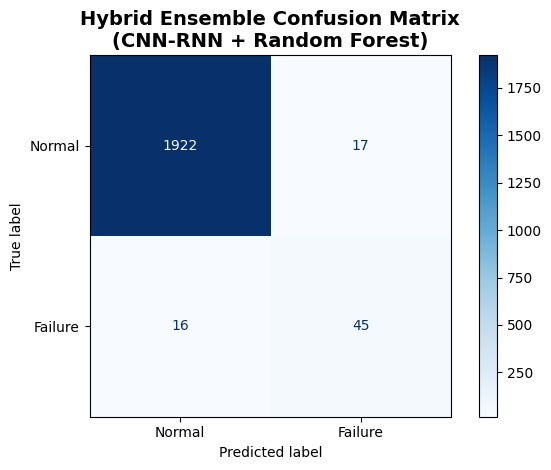


🔍 Confusion Matrix Analysis:
True Negatives (Normal correctly identified):  1,922
False Positives (Normal predicted as Failure): 17
False Negatives (Failure missed):              16
True Positives (Failure correctly identified): 45

📊 Detection Rates:
Specificity (Normal Detection Rate): 99.1%
Sensitivity (Failure Detection Rate): 73.8%
False Positive Rate: 0.9%
False Negative Rate: 26.2%


In [9]:
# 7️⃣ CONFUSION MATRIX VISUALIZATION
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, ensemble_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Failure'])
disp.plot(cmap='Blues')
plt.title("Hybrid Ensemble Confusion Matrix\n(CNN-RNN + Random Forest)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print detailed confusion matrix stats
tn, fp, fn, tp = cm.ravel()
print(f"\n🔍 Confusion Matrix Analysis:")
print(f"True Negatives (Normal correctly identified):  {tn:,}")
print(f"False Positives (Normal predicted as Failure): {fp:,}")
print(f"False Negatives (Failure missed):              {fn:,}")
print(f"True Positives (Failure correctly identified): {tp:,}")

# Calculate rates
tnr = tn / (tn + fp)  # Specificity
fpr = fp / (tn + fp)  # False Positive Rate
fnr = fn / (fn + tp)  # False Negative Rate
tpr = tp / (fn + tp)  # Sensitivity/Recall

print(f"\n📊 Detection Rates:")
print(f"Specificity (Normal Detection Rate): {tnr:.1%}")
print(f"Sensitivity (Failure Detection Rate): {tpr:.1%}")
print(f"False Positive Rate: {fpr:.1%}")
print(f"False Negative Rate: {fnr:.1%}")

# 4. Save Complete Ensemble

In [ ]:
# 8️⃣ SAVE COMPLETE ENSEMBLE SYSTEM
print("💾 Saving hybrid ensemble system...")

# Create directories if needed
os.makedirs("../models", exist_ok=True)
os.makedirs("../results", exist_ok=True)

# Save all ensemble components
model.save("../models/cnn_rnn_hybridensemble.keras")  
joblib.dump(rf, "../models/rf_model_hybridensemble.pkl")
joblib.dump(scaler, "../models/scaler_hybridensemble.pkl")

# Save ensemble metadata
ensemble_config = {
    'cnn_weight': best_weight,
    'rf_weight': 1 - best_weight,
    'threshold': threshold,
    'best_f1': best_f1,
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall
}

import json
with open("../models/hybrid_ensemble_config.json", "w") as f:
    json.dump(ensemble_config, f, indent=2)

# Save predictions for analysis
results_df = pd.DataFrame({
    "True_Label": y_test.reset_index(drop=True),
    "CNN_Probability": cnn_probs,
    "RF_Probability": rf_probs,
    "Ensemble_Probability": ensemble_probs,
    "Predicted_Label": ensemble_preds,
    "Alert_Level": alert_levels  # 🔥 Tiered alert classification
})
results_df.to_csv("../results/hybrid_ensemble_predictions.csv", index=False)

print("✅ Hybrid ensemble system saved successfully!")
print("\n📁 Saved Files:")
print("🧠 ../models/cnn_rnn_hybridensemble.keras")
print("🌲 ../models/rf_model_hybridensemble.pkl")
print("📏 ../models/scaler_hybridensemble.pkl")
print("⚙️ ../models/hybrid_ensemble_config.json")
print("📊 ../results/hybrid_ensemble_predictions.csv")

print(f"\n🎯 PRODUCTION READY MODEL:")
print(f"F1 Score: {best_f1:.4f} | Accuracy: {accuracy:.1%}")
print(f"📈 Next: Run 04_advanced_ensemble.ipynb to try stacked ensemble")

💾 Saving hybrid ensemble system...
✅ Hybrid ensemble system saved successfully!

📁 Saved Files:
🧠 ../models/cnn_rnn_hybridensemble.keras
🌲 ../models/rf_model_hybridensemble.pkl
📏 ../models/scaler_hybridensemble.pkl
⚙️ ../models/hybrid_ensemble_config.json
📊 ../results/hybrid_ensemble_predictions.csv

🎯 PRODUCTION READY MODEL:
F1 Score: 0.7317 | Accuracy: 98.4%
📈 Next: Run 04_advanced_ensemble.ipynb to try stacked ensemble
